In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import sys
import os 


sys.path.append(os.path.abspath('..'))

from src.data.ingestion import load_data , split_data
from src.data.preprocessing import run_preprocessing_pipeline
from src.features.woe_encoder import WoEEncoder
from src.features.iv_selector import IVSelector

pd.set_option('display.max_columns' , 100)
pd.set_option('display.max_rows' , 100)
pd.set_option('display.float_format' , lambda x : '%.4f' %x) 

plt.rcParams['figure.figsize'] = (12  , 6)
plt.rcParams['figure.dpi'] = 200
sns.set_style('whitegrid')

print("All imports successful")

All imports successful


In [2]:
df = load_data('../data/raw/application_train.csv')

X_train, X_test, y_train, y_test = split_data(df, target_col='TARGET', test_size=0.2, random_state=42)

print(f"\nX_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")

Data loaded successfully — Shape: (307511, 122)
Train set : 246,008 rows
Test set  : 61,503 rows
Default rate in train : 8.07%
Default rate in test  : 8.07%

X_train shape : (246008, 121)
X_test shape  : (61503, 121)
y_train shape : (246008,)
y_test shape  : (61503,)


In [3]:
# Run all preprocessing steps in one go
# This will:
# 1. Fix anomalies (DAYS_EMPLOYED 365243, CODE_GENDER XNA)
# 2. Create new features (AGE_YEARS, CREDIT_TO_INCOME_RATIO etc.)
# 3. Create missing indicators for key columns
# 4. Drop columns with more than 50% missing values
# 5. Impute remaining missing values
# 6. Winsorize outliers

X_train_clean, X_test_clean = run_preprocessing_pipeline(X_train, X_test)


STARTING PREPROCESSING PIPELINE

--- Step 1: Fix Anomalies ---
Fixed DAYS_EMPLOYED anomaly — 44143 rows replaced with NaN
Fixed CODE_GENDER anomaly  — 2 rows replaced with NaN
Fixed DAYS_EMPLOYED anomaly — 11231 rows replaced with NaN
Fixed CODE_GENDER anomaly  — 2 rows replaced with NaN

--- Step 2: Create New Features ---
Created 6 new features:
  - AGE_YEARS
  - YEARS_EMPLOYED
  - CREDIT_TO_INCOME_RATIO
  - ANNUITY_TO_INCOME_RATIO
  - CREDIT_TO_ANNUITY_RATIO
  - EMPLOYMENT_TO_AGE_RATIO
Created 6 new features:
  - AGE_YEARS
  - YEARS_EMPLOYED
  - CREDIT_TO_INCOME_RATIO
  - ANNUITY_TO_INCOME_RATIO
  - CREDIT_TO_ANNUITY_RATIO
  - EMPLOYMENT_TO_AGE_RATIO

--- Step 3: Create Missing Indicators ---
Created missing indicator — EXT_SOURCE_1_IS_MISSING
Created missing indicator — EXT_SOURCE_3_IS_MISSING
Created missing indicator — OWN_CAR_AGE_IS_MISSING
Created missing indicator — OCCUPATION_TYPE_IS_MISSING
Created missing indicator — DAYS_EMPLOYED_IS_MISSING
Created missing indicator — EXT

In [4]:
# Initialize the WoE encoder with max 10 bins per numerical feature
woe_encoder = WoEEncoder(max_bins=10)

# Fit on training data only
# This calculates WoE tables for all 91 features
woe_encoder.fit(X_train_clean, y_train)

Fitting WoE Encoder on 91 features...
WoE Encoder fitted successfully on 91 features


In [5]:
# Get IV values for all features from the fitted WoE encoder
iv_dataframe = woe_encoder.get_all_iv_values()

# Initialize IV selector
# min_iv = 0.02 means drop anything below 0.02 (useless)
# max_iv = 0.5  means flag anything above 0.5 (suspicious leakage)
iv_selector = IVSelector(min_iv=0.02, max_iv=0.5)

# Fit the selector on the IV dataframe
iv_selector.fit(iv_dataframe)

IV FEATURE SELECTION SUMMARY
Total features evaluated  : 91
Features selected         : 30
Features dropped (low IV) : 61
Features flagged (high IV): 0

Selected Features (IV between 0.02 and 0.5):
  EXT_SOURCE_3                                  IV=0.3140  (Strong)
  EXT_SOURCE_2                                  IV=0.3029  (Strong)
  CREDIT_TO_ANNUITY_RATIO                       IV=0.1429  (Medium)
  DAYS_EMPLOYED                                 IV=0.1076  (Medium)
  YEARS_EMPLOYED                                IV=0.1069  (Medium)
  AMT_GOODS_PRICE                               IV=0.0910  (Weak)
  EMPLOYMENT_TO_AGE_RATIO                       IV=0.0869  (Weak)
  DAYS_BIRTH                                    IV=0.0866  (Weak)
  AGE_YEARS                                     IV=0.0861  (Weak)
  ORGANIZATION_TYPE                             IV=0.0751  (Weak)
  NAME_INCOME_TYPE                              IV=0.0560  (Weak)
  OCCUPATION_TYPE                               IV=0.0504  (Weak)


In [11]:
selected_features = iv_selector.get_selected_features()

print(f"Transforming {len(selected_features)} selected features...")

X_train_woe = woe_encoder.transform(X_train_clean[selected_features])
X_test_woe  = woe_encoder.transform(X_test_clean[selected_features])

print(f"\nX_train_woe shape : {X_train_woe.shape}")
print(f"X_test_woe shape  : {X_test_woe.shape}")
print(f"\nSample of WoE transformed data:")
X_train_woe.head()

Transforming 30 selected features...

X_train_woe shape : (246008, 30)
X_test_woe shape  : (61503, 30)

Sample of WoE transformed data:


,EXT_SOURCE_3,EXT_SOURCE_2,CREDIT_TO_ANNUITY_RATIO,DAYS_EMPLOYED,YEARS_EMPLOYED,AMT_GOODS_PRICE,EMPLOYMENT_TO_AGE_RATIO,DAYS_BIRTH,AGE_YEARS,ORGANIZATION_TYPE,NAME_INCOME_TYPE,OCCUPATION_TYPE,NAME_EDUCATION_TYPE,AMT_CREDIT,DAYS_LAST_PHONE_CHANGE,CODE_GENDER,DAYS_ID_PUBLISH,REGION_POPULATION_RELATIVE,REGION_RATING_CLIENT_W_CITY,TOTALAREA_MODE,REGION_RATING_CLIENT,DAYS_REGISTRATION,FLOORSMAX_AVG,FLOORSMAX_MEDI,FLOORSMAX_MODE,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_AVG,AMT_ANNUITY,YEARS_BEGINEXPLUATATION_MODE,NAME_FAMILY_STATUS
181648,-0.6385,0.4413,0.2334,0.3017,0.3026,-0.1012,0.2641,0.2184,0.2131,0.0734,-0.0667,-0.0148,-0.4319,-0.0348,0.1555,-0.1540,-0.2815,0.1508,-0.0784,-0.3729,-0.0793,-0.0178,-0.2986,-0.2983,-0.2999,-0.1890,-0.1945,-0.1571,-0.1679,-0.0749
229245,0.0338,-0.0850,0.3712,0.3386,0.3426,-0.1012,0.3023,-0.0044,-0.0160,-0.0809,-0.0667,0.3682,0.1085,-0.1966,0.1422,0.2502,0.1389,0.0717,0.3881,0.1182,0.3548,0.1051,0.0694,0.0682,0.0636,0.1232,0.1231,-0.1571,0.1183,-0.0749
122525,-0.4473,0.0386,-0.0971,0.1550,-0.3897,0.0488,0.1993,-0.2711,-0.2766,0.1518,0.1829,-0.0148,0.1085,0.0466,-0.2173,0.2502,0.0500,0.2007,-0.0784,-0.2686,0.3548,-0.1251,-0.4792,-0.4924,-0.4896,-0.3540,-0.3496,0.1453,-0.3560,0.2292
306311,0.0886,-0.5025,0.3712,-0.3975,0.1755,0.5462,0.1993,-0.1367,-0.1379,0.1518,-0.0667,-0.0148,0.1085,0.2103,-0.2872,0.2502,0.2133,-0.0061,-0.0784,0.1008,-0.0793,0.1051,0.0921,0.0888,0.0895,-0.0039,-0.0068,0.0424,-0.0083,0.2292
300658,0.0338,0.9338,-0.5264,0.3017,0.3026,0.0831,-0.3954,0.4070,0.3952,0.4065,-0.0667,-0.5925,0.0723,-0.0348,0.1557,-0.1540,0.2133,0.0717,-0.0784,0.1182,-0.0793,0.0993,0.0694,0.0682,0.0636,0.1232,0.1231,0.1453,0.1183,0.2292


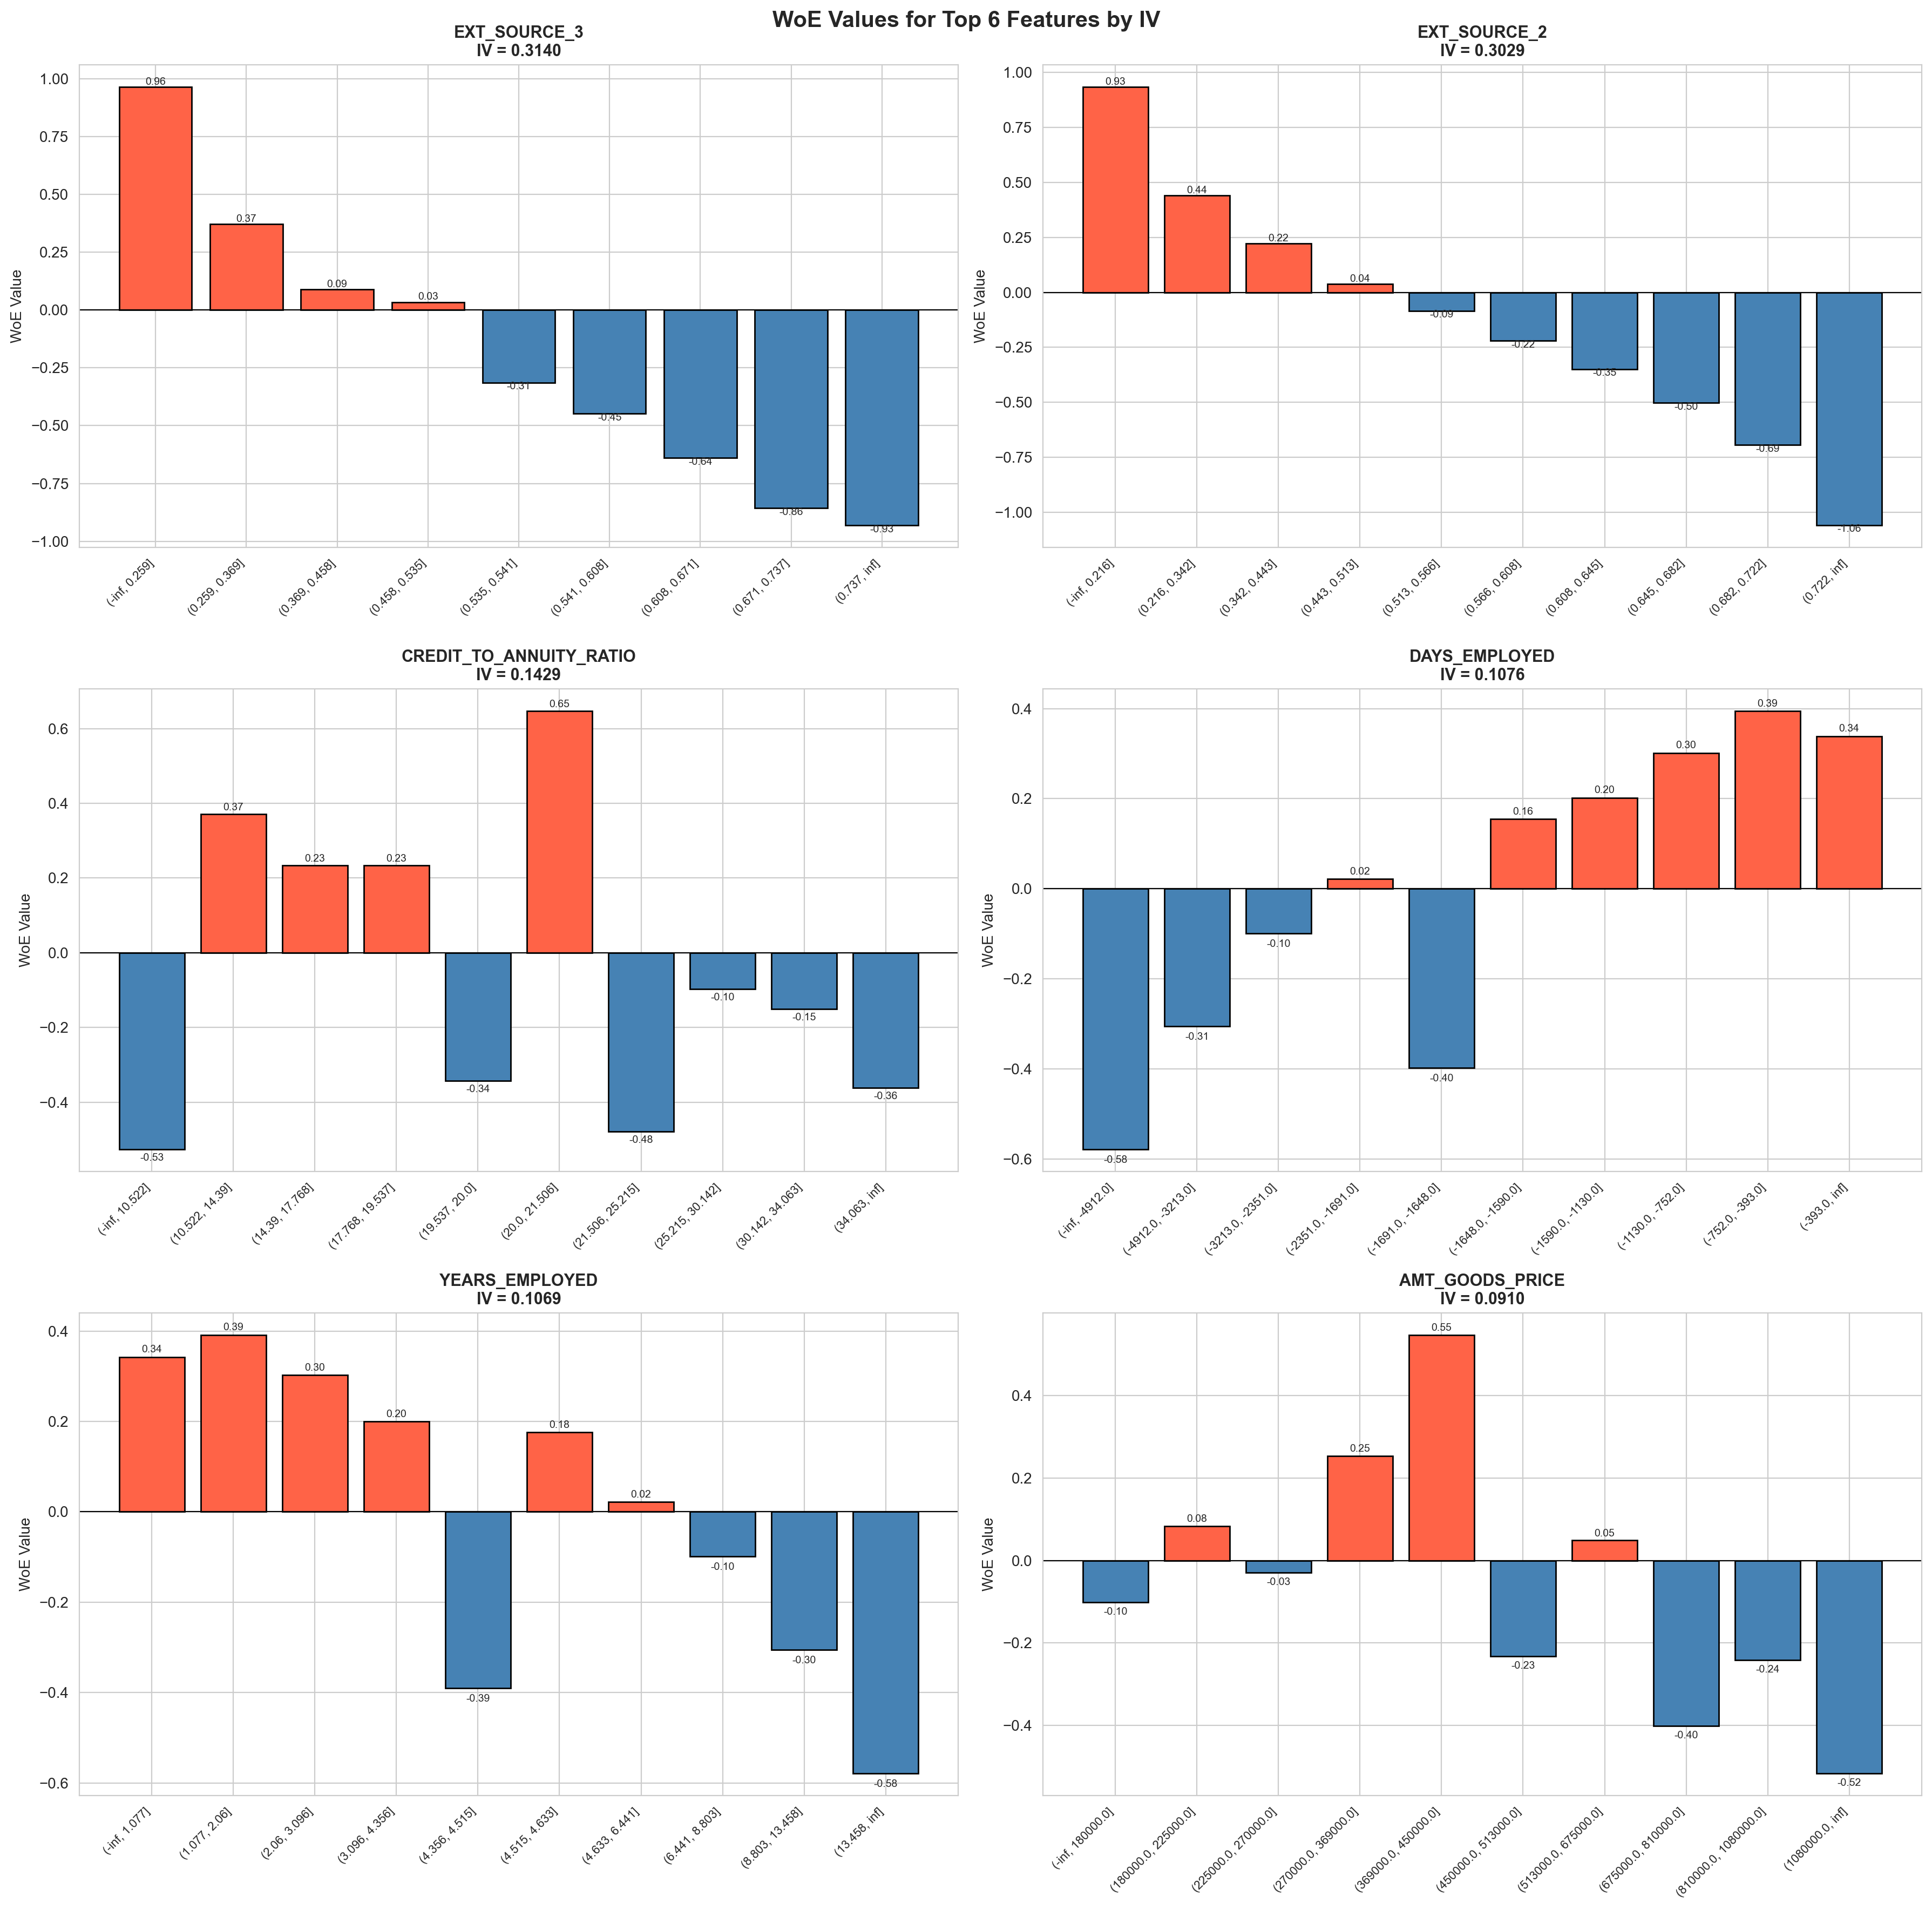

Plot saved to docs/woe_top6_features.png


In [12]:
top_6_features = iv_dataframe.head(6)['feature'].tolist()

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for i, feature in enumerate(top_6_features):

    woe_table = woe_encoder.get_woe_table(feature)

    # Convert bin to string for plotting
    woe_table['bin_str'] = woe_table['bin'].astype(str)

    # Color bars — positive WoE is red (risky), negative WoE is green (safe)
    colors = ['tomato' if w > 0 else 'steelblue' for w in woe_table['WoE']]

    axes[i].bar(range(len(woe_table)), woe_table['WoE'], color=colors, edgecolor='black')
    axes[i].set_xticks(range(len(woe_table)))
    axes[i].set_xticklabels(woe_table['bin_str'], rotation=45, ha='right', fontsize=8)
    axes[i].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    axes[i].set_title(f'{feature}\nIV = {iv_dataframe[iv_dataframe["feature"]==feature]["IV"].values[0]:.4f}',
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('WoE Value')

    # Add value labels on bars
    for j, val in enumerate(woe_table['WoE']):
        axes[i].text(j, val + 0.01 if val >= 0 else val - 0.03,
                     f'{val:.2f}', ha='center', fontsize=7)

plt.suptitle('WoE Values for Top 6 Features by IV', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/woe_top6_features.png', bbox_inches='tight')
plt.show()

print("Plot saved to docs/woe_top6_features.png")

In [13]:
import joblib
import os

# Create processed data directory if it does not exist
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Save the WoE transformed train and test sets
X_train_woe.to_csv('../data/processed/X_train_woe.csv', index=True)
X_test_woe.to_csv('../data/processed/X_test_woe.csv', index=True)

# Save the target variables
y_train.to_csv('../data/processed/y_train.csv', index=True)
y_test.to_csv('../data/processed/y_test.csv', index=True)

# Save the fitted WoE encoder and IV selector
# We will need these later in the API to transform new applicant data
joblib.dump(woe_encoder, '../models/woe_encoder.pkl')
joblib.dump(iv_selector, '../models/iv_selector.pkl')

print("All files saved successfully")
print("\nSaved to data/processed/:")
print("  - X_train_woe.csv")
print("  - X_test_woe.csv")
print("  - y_train.csv")
print("  - y_test.csv")
print("\nSaved to models/:")
print("  - woe_encoder.pkl")
print("  - iv_selector.pkl")

All files saved successfully

Saved to data/processed/:
  - X_train_woe.csv
  - X_test_woe.csv
  - y_train.csv
  - y_test.csv

Saved to models/:
  - woe_encoder.pkl
  - iv_selector.pkl


In [14]:
print("=" * 60)
print("WoE AND IV ANALYSIS SUMMARY")
print("=" * 60)

print(f"""
FEATURE SELECTION RESULTS
--------------------------
Total features after preprocessing : 91
Features selected after IV filter  : 30
Features dropped (IV < 0.02)       : 61
Features flagged (IV > 0.5)        : 0

TOP 10 FEATURES BY PREDICTIVE POWER
-------------------------------------""")

top10 = iv_dataframe.head(10)
for _, row in top10.iterrows():
    iv_val = row['IV']
    if iv_val >= 0.3:
        strength = "Strong"
    elif iv_val >= 0.1:
        strength = "Medium"
    else:
        strength = "Weak"
    print(f"  {row['feature']:<45} IV={iv_val:.4f}  ({strength})")

print(f"""
KEY OBSERVATIONS
-----------------
- EXT_SOURCE_2 and EXT_SOURCE_3 are the strongest predictors
  These are external credit bureau scores — exactly as expected
- CREDIT_TO_ANNUITY_RATIO and YEARS_EMPLOYED are medium predictors
  These measure debt burden and employment stability
- No features flagged for data leakage (IV > 0.5) — clean dataset
- All WoE values make business sense:
  Younger age bins have positive WoE (more defaulters)
  Higher income bins have negative WoE (fewer defaulters)

WHAT IS SAVED
--------------
- data/processed/X_train_woe.csv  — WoE transformed train features
- data/processed/X_test_woe.csv   — WoE transformed test features
- data/processed/y_train.csv      — train target variable
- data/processed/y_test.csv       — test target variable
- models/woe_encoder.pkl          — fitted WoE encoder
- models/iv_selector.pkl          — fitted IV selector
""")

print("=" * 60)
print("WoE AND IV ANALYSIS COMPLETE — Ready for Phase 6 Model Training")
print("=" * 60)

WoE AND IV ANALYSIS SUMMARY

FEATURE SELECTION RESULTS
--------------------------
Total features after preprocessing : 91
Features selected after IV filter  : 30
Features dropped (IV < 0.02)       : 61
Features flagged (IV > 0.5)        : 0

TOP 10 FEATURES BY PREDICTIVE POWER
-------------------------------------
  EXT_SOURCE_3                                  IV=0.3140  (Strong)
  EXT_SOURCE_2                                  IV=0.3029  (Strong)
  CREDIT_TO_ANNUITY_RATIO                       IV=0.1429  (Medium)
  DAYS_EMPLOYED                                 IV=0.1076  (Medium)
  YEARS_EMPLOYED                                IV=0.1069  (Medium)
  AMT_GOODS_PRICE                               IV=0.0910  (Weak)
  EMPLOYMENT_TO_AGE_RATIO                       IV=0.0869  (Weak)
  DAYS_BIRTH                                    IV=0.0866  (Weak)
  AGE_YEARS                                     IV=0.0861  (Weak)
  ORGANIZATION_TYPE                             IV=0.0751  (Weak)

KEY OBSERVATI